# Exercise 01: Generative Models Fundamentals
## AIAT 124 - Generative AI

---

## Learning Objectives

In this exercise, you will:
- Compare generative vs discriminative models
- Work with latent spaces
- Implement a basic generative model
- Generate synthetic data

---

## Real-World Context

You are exploring generative models to create synthetic data for data augmentation or creative applications.

---


In [1]:
# Setup: everything the tasks need is imported here — run this first.
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('Setup complete!')


Setup complete!


## Task 1: Model Comparison (30 points)

Compare a generative and a discriminative model on the same dataset (the worked example at the bottom of this notebook trains the *discriminative* side for you — reuse it).

**Requirements:**
- Train both model types (e.g., `GaussianNB` as the generative model vs the neural / logistic classifier as the discriminative one — see unit example 01)
- Compare test accuracy
- Show something only the generative model can do: **sample new data points** from it
- Document your findings in a short comment


In [2]:
# TODO Task 1: train a generative model (e.g., sklearn GaussianNB on the
# digits data) and compare it with the discriminative classifier from the
# worked example below. Then sample new points from the generative model
# (hint: use its per-class mean theta_ and variance var_, as in example 01).
def task1_model_comparison():
    # YOUR CODE HERE
    pass


## Task 2: Latent Space Exploration (40 points)

Work with latent spaces: encoding, decoding, and sampling (unit examples 04 and 12 show every building block).

**Requirements:**
- Implement an encoder/decoder (an autoencoder or a small VAE)
- Sample from the latent space and decode the samples
- Visualize the latent space (scatter of encoded digits, colored by label)
- Generate and display a few samples


In [3]:
# TODO Task 2: build a small autoencoder or VAE for the 8x8 digits
# (input_dim=64), train it, then (a) scatter-plot the latent codes colored
# by digit label and (b) decode a few random latent vectors into images.
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        # YOUR CODE HERE: define encoder and decoder layers
        pass

def task2_latent_exploration():
    # YOUR CODE HERE: train, visualize latent space, decode samples
    pass


## Task 3: Simple Generative Model (30 points)

Implement a basic generative model — a Gaussian Mixture Model (`sklearn.mixture.GaussianMixture`, see unit example 03) or a simple VAE (unit example 04).

**Requirements:**
- Choose an appropriate model and train it on the digits data
- Generate new samples from the trained model
- Evaluate quality: visually (plot generated digits) and quantitatively (e.g., held-out log-likelihood for a GMM)


In [4]:
# TODO Task 3: fit your chosen generative model, sample new digits from it,
# plot them, and report a quantitative score (e.g., gmm.score(X_test)).
def task3_generative_model():
    # YOUR CODE HERE
    pass


---

## Submission

**Submission**: Complete notebook with all tasks implemented

**Grading**: 100 points total (Task 1: 30, Task 2: 40, Task 3: 30)


## 🌍 Worked Example — a Discriminative Baseline (use it in Task 1)

**Industry context:** postal services and banks have classified handwritten digits at scale since the 1980s.

Below is a complete **discriminative** model: a neural network classifying real 8×8 digit images (sklearn's built-in dataset — no download needed). It models p(label | image) and nothing else — your Task 1 job is to put a *generative* model next to it and show what the generative side can do that this one cannot.


Test accuracy on real handwritten digits: 96.9%


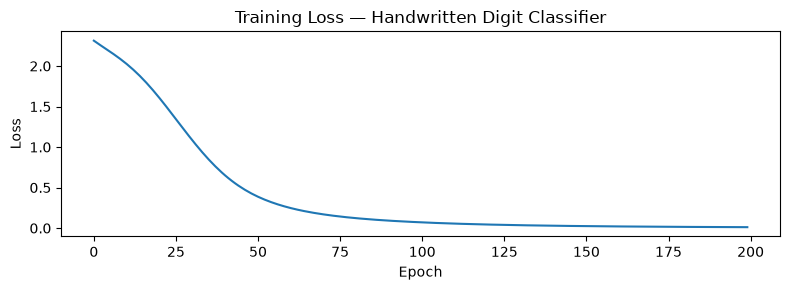

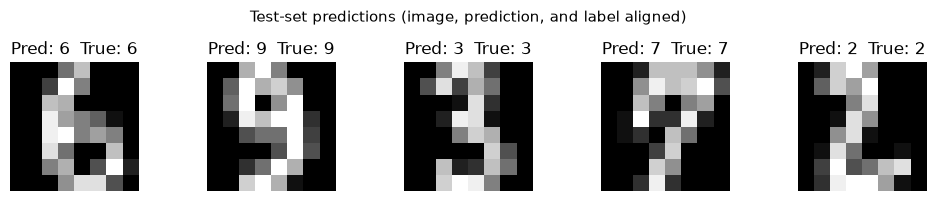

In [5]:
# WHAT/WHY: a complete discriminative baseline — train a small neural network
# to classify 8x8 digit images, report test accuracy, and display test images
# with their predicted and true labels. Task 1 compares this against a
# generative model you build.
torch.manual_seed(0)

# ── Real digit images (1797 samples, 8×8 pixels) ──────────────────────────
digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target

# Split features, labels AND raw images together so they stay aligned
X_tr, X_te, y_tr, y_te, img_tr, img_te = train_test_split(
    X, y, digits.images, test_size=0.2, random_state=42)

X_tr_t = torch.tensor(X_tr); y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te); y_te_t = torch.tensor(y_te, dtype=torch.long)

# ── Two-hidden-layer classifier: 64 pixels → 10 class scores ──────────────
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()
losses    = []

# ── Training loop: full-batch gradient descent, 200 epochs ────────────────
for epoch in range(200):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Evaluate on the held-out test split ───────────────────────────────────
model.eval()
with torch.no_grad():
    test_preds = model(X_te_t).argmax(1)
    acc = (test_preds == y_te_t).float().mean().item()
print(f"Test accuracy on real handwritten digits: {acc*100:.1f}%")

# ── Plot training loss ────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Handwritten Digit Classifier"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ── Show the first 5 TEST images with their predicted and true labels ─────
# (img_te was split together with X_te, so image i matches prediction i)
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(img_te[i], cmap='gray')
    ax.set_title(f"Pred: {test_preds[i].item()}  True: {y_te[i]}")
    ax.axis('off')
plt.suptitle("Test-set predictions (image, prediction, and label aligned)", fontsize=11)
plt.tight_layout(); plt.show()


## 📝 Summary

The worked example above gave you a **discriminative** baseline (a p(label | image) classifier with its test accuracy printed). The three tasks ask you to build the **generative** side yourself:

- Task 1 — put a generative classifier next to the baseline and *sample* from it
- Task 2 — build an encoder/decoder and explore its latent space
- Task 3 — train a standalone generative model and grade its samples

Once your task cells run, this notebook will contain your own generative-modeling evidence: samples, latent-space plots, and a quantitative score. Unit examples 01, 03, 04, and 12 contain every technique needed.

**Next steps:** Unit 2 applies generation to text; Unit 3 to images with diffusion models.


## 📚 References & Further Reading

**Foundational:**
- Ng & Jordan (2001) — [On Discriminative vs. Generative Classifiers](https://papers.nips.cc/paper/2020-on-discriminative-vs-generative-classifiers)
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- Goodfellow et al. (2016) — [Deep Learning Book](https://www.deeplearningbook.org/), Ch. 20

**PyTorch Docs:**
- [torch.nn — Building Blocks](https://pytorch.org/docs/stable/nn.html)
- [Autograd — Automatic Differentiation](https://pytorch.org/docs/stable/autograd.html)
